# Anomalous Financial Transaction Detection

본 대회의 과제는 금융 거래 데이터에서 **이상 거래를 탐지하는 기능**을 개선하고 활용도를 높이는 분류 AI모델을 개발하는 것입니다. 

특히, 클래스 불균형 문제를 해결하기 위해 오픈소스 생성형 AI 모델을 활용하여 부족한 클래스의 데이터를 보완하고, 이를 통해 분류 모델의 성능을 향상시키는 것이 핵심 목표입니다. 

이러한 접근을 통해 금융보안에 특화된 데이터 분석 및 활용 역량을 강화하여 전문 인력을 양성하고, 금융권의 AI 활용 어려움에 따른 해결 방안을 함께 모색하며 금융 산업의 AI 활용 활성화를 지원하는 것을 목표로 합니다.

# Import Library

In [1]:
# 제출 파일 생성 관련
import os
import zipfile

# 데이터 처리 및 분석
import pandas as pd
import numpy as np
from scipy import stats
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt

# 머신러닝 전처리
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder

# 머신러닝 모델
import xgboost as xgb

# 합성 데이터 생성
from sdv.metadata import SingleTableMetadata
from sdv.single_table import CTGANSynthesizer

# To ignore all warnings
import warnings
warnings.filterwarnings('ignore')

# 생성 🏭

# Load Data

In [2]:
train_all = pd.read_csv("data/train_kor.csv") # 경로는 각자 지정
test_all = pd.read_csv("data/test_kor.csv") # 경로는 각자 지정

In [3]:
train_all.head()

,샘플 식별자 번호,고객 출생년도,고객 성별,고객명,주민번호,고객 등록일자,고객 등급,3개월 이내 금융/공동인증서 발급 여부,3개월 이내 사설인증서 발급 여부,3개월 이내 보안카드 및 OTP 발급 여부,...,마지막 ATM 거래 일자,마지막 영업점 거래 일자,7일 거래내역 중 1천만원 이상 입금 여부,7일 거래내역 중 미거래 계좌 여부,수취계좌의 거래중지계좌 해당 여부,3시간 이내 해당 수취계좌에 이체 횟수,해당 수취계좌와 거래한 횟수,60세 이후 iOS 첫 사용자,사기 시나리오 (예측 목표),계좌의 거래 재개 일자
0,TRAIN_000000,1980,male,이상호,BJWQxd-WBASPLJ,2003-01-06 18:38:01,B,0,1,0,...,2003-01-22 23:38:48,2003-01-22 23:38:48,1,1,1,0,0,0,m,2003-01-22 23:38:48
1,TRAIN_000001,1964,male,박상철,kurCwX-odPUXEt,2003-01-07 16:40:44,C,0,1,0,...,2003-01-21 21:29:08,2003-01-31 00:19:46,0,1,0,0,0,0,m,2003-01-19 21:29:08
2,TRAIN_000002,1982,female,조옥자,OiERQa-CTXBoaX,2003-01-11 14:08:36,B,1,1,0,...,2003-01-31 07:13:28,2003-01-31 07:13:28,0,0,1,1,1,0,m,2003-01-31 07:13:28
3,TRAIN_000003,1982,female,조옥자,OiERQa-CTXBoaX,2003-01-11 14:08:36,B,1,1,1,...,2003-01-31 11:49:56,2003-01-31 07:13:28,1,1,0,0,0,0,m,2003-01-31 07:13:28
4,TRAIN_000004,1982,female,조옥자,OiERQa-CTXBoaX,2003-01-11 14:08:36,B,1,1,1,...,2003-01-31 11:49:56,2003-01-31 07:13:28,1,0,0,1,1,0,m,2003-01-31 07:13:28


In [4]:
train = train_all.drop(columns="샘플 식별자 번호")

In [5]:
'''
(*) 리더보드 산식 중 생성데이터의 익명성(TCAP)채점을 위해 각 클래스 별로 1000개의 생성데이터가 반드시 필요합니다.
(*) 본 베이스 라인에서는 "계좌의 거래 재개 일자" 13종류에 대해 1000개씩 , 총 13,000개의 데이터를 생성할 예정입니다.
(*) 분류 모델 성능 개선을 위해 생성 데이터를 활용하는 것에는 생성 데이터의 Row 개수에 제한이 없습니다. 단, 리더보드 평가를 위해 제출을 하는 생성 데이터 프레임은 익명성(TCAP) 평가를 위함이며, 위의 조건을 갖춘 생성 데이터를 제출해야합니다.
'''
N_CLS_PER_GEN = 1000


In [6]:

# 이상치 처리 함수
def handle_outliers(series, n_std=3):
    mean = series.mean()
    std = series.std()
    z_scores = np.abs(stats.zscore(series))
    return series.mask(z_scores > n_std, mean)

# Time_difference 컬럼을 총 초로 변환 및 이상치 처리
train['거래시간_차이_seconds'] = pd.to_timedelta(train['직전 거래와의 시간 차이']).dt.total_seconds()
train['거래시간_차이_seconds'] = handle_outliers(train['거래시간_차이_seconds'])


# 모든 Fraud_Type 목록 생성 (m 포함)
fraud_types = train['사기 시나리오 (예측 목표)'].unique()

# 모든 합성 데이터를 저장할 DataFrame 초기화
all_synthetic_data = pd.DataFrame()

N_SAMPLE = 100

# 각 Fraud_Type에 대해 합성 데이터 생성 및 저장
for fraud_type in tqdm(fraud_types):
    
    # 해당 Fraud_Type에 대한 서브셋 생성
    subset = train[train["사기 시나리오 (예측 목표)"] == fraud_type]

    # 모든 Fraud_Type에 대해 100개씩 샘플링
    subset = subset.sample(n=N_SAMPLE, random_state=42)
    
    # Time_difference 열 제외 (초 단위로 변환된 컬럼만 사용)
    subset = subset.drop('직전 거래와의 시간 차이', axis=1)
    
    # 메타데이터 생성 및 모델 학습
    metadata = SingleTableMetadata()

    metadata.detect_from_dataframe(subset)
    metadata.set_primary_key(None)

    # 데이터 타입 설정
    column_sdtypes = {
        '거래 전 잔액': 'numerical',
        '거래 후 잔액': 'numerical',
        '주민번호': 'categorical',  
        '고객명': 'categorical',
        '암호화된 계좌번호': 'categorical',
        '거래에 사용한 단말기 IP주소': 'ipv4_address',  
        '거래 발생 위치': 'categorical',
        '수취인 계좌번호': 'categorical',
        '계좌의 거래 재개 일자': 'categorical',
        '거래시간_차이_seconds': 'numerical',
        '고객 출생년도': 'numerical'
    }

    # 각 컬럼에 대해 데이터 타입 설정
    for column, sdtype in column_sdtypes.items():
        metadata.update_column(
            column_name=column,
            sdtype=sdtype
        )
        
    synthesizer = CTGANSynthesizer(
                            metadata,
                            epochs=100
                        )
    synthesizer.fit(subset)

    synthetic_subset = synthesizer.sample(num_rows=N_CLS_PER_GEN)
    
    # 생성된 Time_difference_seconds의 이상치 처리
    synthetic_subset['거래시간_차이_seconds'] = handle_outliers(synthetic_subset['거래시간_차이_seconds'])
    
    # Time_difference_seconds를 다시 timedelta로 변환
    synthetic_subset['직전 거래와의 시간 차이'] = pd.to_timedelta(synthetic_subset['거래시간_차이_seconds'], unit='s')
    
    # Time_difference_seconds 컬럼 제거
    synthetic_subset = synthetic_subset.drop('거래시간_차이_seconds', axis=1)
    
    # 생성된 데이터를 all_synthetic_data에 추가
    all_synthetic_data = pd.concat([all_synthetic_data, synthetic_subset], ignore_index=True)
# 최종 결과 확인
print("\nFinal All Synthetic Data Shape:", all_synthetic_data.shape)

100%|██████████| 13/13 [02:58<00:00, 13.77s/it]


Final All Synthetic Data Shape: (13000, 63)


In [7]:
all_synthetic_data.head() # 잘 변환되었는지 확인하는 과정입니다.

,고객 출생년도,고객 성별,고객명,주민번호,고객 등록일자,고객 등급,3개월 이내 금융/공동인증서 발급 여부,3개월 이내 사설인증서 발급 여부,3개월 이내 보안카드 및 OTP 발급 여부,3개월 이내 개인정보 수정 여부,...,마지막 영업점 거래 일자,7일 거래내역 중 1천만원 이상 입금 여부,7일 거래내역 중 미거래 계좌 여부,수취계좌의 거래중지계좌 해당 여부,3시간 이내 해당 수취계좌에 이체 횟수,해당 수취계좌와 거래한 횟수,60세 이후 iOS 첫 사용자,사기 시나리오 (예측 목표),계좌의 거래 재개 일자,직전 거래와의 시간 차이
0,1950,male,김영호,EQTKgS-IBtoZCh,2003-03-12 21:28:24,C,0,1,1,1,...,2030-12-12 02:24:25,0,0,1,0,3,0,m,2031-07-08 04:20:05,0 days 00:01:38
1,1978,female,김영환,oYOHiy-JMIOltt,2003-05-07 18:52:22,C,1,1,0,1,...,2036-11-05 06:26:31,0,1,1,0,2,0,m,2022-05-16 14:54:35,0 days 00:01:38
2,1962,male,최현준,YuMAdG-cURFSEF,2007-10-12 09:12:28,B,0,0,1,1,...,2009-11-05 18:40:59,0,0,1,0,0,0,m,2005-10-13 15:10:01,0 days 00:01:38
3,1978,male,서지은,RaCeMo-htYjkES,2004-07-13 09:51:48,B,0,1,1,0,...,2028-10-30 12:29:31,0,0,0,0,0,0,m,2027-12-23 14:44:30,0 days 00:01:38
4,1966,female,허주원,jsjZKO-rIpIrnm,2003-10-19 13:58:31,B,1,1,1,1,...,2024-05-30 20:33:11,1,0,0,0,0,0,m,2024-08-29 13:14:08,0 days 00:01:38


## 원본 데이터와 concat

In [8]:
origin_train = train_all.drop(columns="샘플 식별자 번호")
train_total = pd.concat([origin_train, all_synthetic_data])
train_total.shape

(133000, 63)

In [9]:
# # 만약 train_x에 Fraud_Type 컬럼이 존재한다면
# gender_fraud_rate = train_all.groupby(['고객 성별', '사기 시나리오 (예측 목표)']).size().unstack().fillna(0)
# gender_fraud_rate['사기 시나리오 (예측 목표)'] = gender_fraud_rate.drop('m', axis=1).sum(axis=1) / gender_fraud_rate.sum(axis=1)
# print(gender_fraud_rate)


# Data Preprocessing 1 : Select x, y

In [10]:
train_x = train_total.drop(columns=['사기 시나리오 (예측 목표)'])
train_y = train_total['사기 시나리오 (예측 목표)']

test_x = test_all.drop(columns=['샘플 식별자 번호'])

In [ ]:

def add_custom_features(df):
	df = df.copy()
	current_year = 2024

	# 📌 1. 고객 나이
	df['고객 나이'] = current_year - df['고객 출생년도']

	# 📌 2. 거리 관련 변수
	df['Is_Large_Distance'] = (df['직전 거래 발생지와의 거리 차이'] >= 300).astype(int)
	
	# 📌 3. A
	vpn_login_types = ['a', 'b']
	df['Is_Large_Distance'] = (df['직전 거래 발생지와의 거리 차이'] >= 300).astype(int)
	df['A'] = (
	        df['거래 시스템 접근 매체(a: ID/PW 로그인, b: 패턴, c: 생체로그인, d: 금융/공동 인증서, e: 사설인증서, f: 보안카드, g: OTP, h: 보안카드+OTP)'].isin(vpn_login_types) &
	        (df['Is_Large_Distance'] == 1)
	    ).astype(int)
	
	# 📌 4. B
	df['B'] = (
	    (df['고객 등급'] == 'C') &
	    ((df['모바일 로밍 여부'] == 1) |
	     (df['탈옥 및 루팅 여부'] == 1) |
	     (df['VPN 사용 여부'] == 1)) &
	    (df['거래 채널'] != 'Others')
	).astype(int)
	
	# 📌 5. C
	df['C'] = (
	    (df['거래 채널'] != 'Others') &
	    ((df['키로깅 여부'] == 1) | (df['원격제어 여부'] == 1))
	).astype(int)
	
	# 📌 6. D
	df['D'] = (
	    (df['7일 거래내역 중 미사용 단말 여부'] == 1) &
	    (df['거래 시스템 접근 매체(a: ID/PW 로그인, b: 패턴, c: 생체로그인, d: 금융/공동 인증서, e: 사설인증서, f: 보안카드, g: OTP, h: 보안카드+OTP)'].isin(vpn_login_types)) &
	    (df['거래 성공/실패 여부'] == 0) &
	    (df['에러코드(a: 에러없음, b: 시스템 오류, c: 잔액부족, d: 이체한도초과, e: 계좌정보 오류, f: 계좌이체 거부)'] == 'a') &
	    (df['거래 채널'] != 'Others')
	).astype(int)
	
	# 📌 7. E
	df['E'] = ((df['거래 채널'] == 'ATM') & (df['7일 거래내역 중 1천만원 이상 입금 여부'] == 1)).astype(int)
	
	# 📌 8. F
	df['F'] = (
	    (df['거래 채널'] == 'Others') &
	    (df['거래에 사용한 단말기 OS'].isin(['Others', 'Windows'])) &
	    (df['30일 이내 계좌 정지 해제 여부'] == 1)
	).astype(int)
	
	# 📌 9. G
	df['G'] = (
	    (df['7일 거래내역 중 1천만원 이상 입금 여부'] == 1) &
	    (df['30일 이내 계좌 정지 해제 여부'] == 1)
	).astype(int)
	
	# 📌 10. H
	df['H'] = (
	    (df['1일 거래 한도 잔여액'] > 3000000) &
	    (df['1개월 거래내역 중 최대 이체(출금) 금액'] <= 14000000)
	).astype(int)
	
	# 📌 11. I
	df['I'] = (
	    (df['거래 성공/실패 여부'] == 0) &
	    (df['이체 금액'] <= -2500000) &
	    (df['1개월 새벽 거래내역 중 최대 이체(출금) 금액'] > 0) &
	    (df['1개월 새벽 거래내역 중 최대 이체(출금) 금액'] <= 27000000) &
	    (df['1개월 새벽 거래내역 이체(출금) 금액 표준편처(중앙값)'] <= 14000000)
	).astype(int)
	
	# 📌 12. J
	df['J'] = (
	    (df['수취계좌의 거래중지계좌 해당 여부'] == 1) &
	    (df['7일 거래내역 중 미거래 계좌 여부'] == 1) &
	    (df['3시간 이내 해당 수취계좌에 이체 횟수'] == 0)
	).astype(int)
	
	# 📌 13. K
	df['K'] = (
	    (df['3시간 이내 해당 수취계좌에 이체 횟수'] >= 2) &
	    (df['해당 수취계좌와 거래한 횟수'] >= 2)
	).astype(int)
	
	# 📌 14. L
	df['고객 나이'] = current_year - df['고객 출생년도']
	df['L'] = (
	    (df['고객 나이'] >= 60) &
	    (df['대출 신청 유형(a: 없음, b: 신용대출, c: 담보대출, d: 할부금융, e: 기타)'] != 'a')
	).astype(int)
	
	
	# 📌 15. 급격한 잔액 감소 여부
	df['Is_Sudden_Balance_Drop'] = (df['거래 후 잔액'] < df['거래 전 잔액'] * 0.3).astype(int)
	
	# 📌 16. 비율 기반 파생변수
	df['Amount_Per_Limit_Ratio'] = df['이체 금액'] / (df['1일 거래 한도'] + 1)
	df['Amount_vs_Monthly_Max'] = df['이체 금액'] / (df['1개월 거래내역 중 최대 이체(출금) 금액'] + 1)
	
#######################################################################################333

	# 1. 나이 그룹
	df['Age_Group'] = pd.cut(2025 - df['고객 출생년도'],
						bins=[0, 29, 39, 49, 59, 200],
						labels=['20대 이하', '30대', '40대', '50대', '60대 이상'])

	# 2. 인증 변경 횟수
	auth_cols = ['3개월 이내 금융/공동인증서 발급 여부', '3개월 이내 사설인증서 발급 여부',
				'3개월 이내 보안카드 및 OTP 발급 여부', '3개월 이내 개인정보 수정 여부']
	df['flag_change'] = df[auth_cols].sum(axis=1)

	# 3. 루팅/탈옥 거래 금액
	df['root_amount'] = df.apply(lambda x: x['이체 금액'] if x['탈옥 및 루팅 여부'] == 1 else 0, axis=1)

	# 4. 로밍 거래 금액
	df['roaming_amount'] = df.apply(lambda x: x['이체 금액'] if x['모바일 로밍 여부'] == 1 else 0, axis=1)

	# 5. 잔액 변동
	df['changed_balance'] = df['거래 후 잔액'] - df['거래 전 잔액']

	# 6. 일일 한도 사용 금액
	df['used_day_limit'] = df['1일 거래 한도'] - df['1일 거래 한도 잔여액']

	# 7. 일일 한도 대비 거래 비율
	df['day_limit_ratio'] = df['이체 금액'] / (df['1일 거래 한도'] + 1e-6)

	# 8. 거래 금액 상한선
	df['limit_line'] = df['1개월 거래내역 중 최대 이체(출금) 금액'] + 3 * df['1개월 거래내역 이체(출금) 금액 표준편차(중앙값)']

	# 9. 상한선 초과 여부
	df['exceed_limit'] = (df['이체 금액'] > df['limit_line']).astype(int)

	# 10. 계좌 생성 - 고객 등록 시간 차
	df['time_difference_registration'] = (
		pd.to_datetime(df['계좌 개설 일자']) - pd.to_datetime(df['고객 등록일자'])
	).dt.total_seconds() / 3600

	# 11. 계좌 생성 - 거래 발생 시간 차
	df['time_difference_transaction'] = (
		pd.to_datetime(df['거래일자']) - pd.to_datetime(df['계좌 개설 일자'])
	).dt.total_seconds() / 3600

	# 12. 마지막 ATM 거래 후 경과 시간
	df['last_atm'] = (
		pd.to_datetime(df['거래일자']) - pd.to_datetime(df['마지막 ATM 거래 일자'])
	).dt.total_seconds() / 3600

	# 13. 마지막 지점 거래 후 경과 시간
	df['last_bank'] = (
		pd.to_datetime(df['거래일자']) - pd.to_datetime(df['마지막 영업점 거래 일자'])
	).dt.total_seconds() / 3600

	# 14. 거래 재개 후 경과 시간
	df['last_resumed'] = (
		pd.to_datetime(df['거래일자']) - pd.to_datetime(df['계좌의 거래 재개 일자'])
	).dt.total_seconds() / 3600
	return df


In [12]:
train_x = add_custom_features(train_x)
test_x = add_custom_features(test_x)

In [13]:
# 컬럼 제거
def drop_columns(df_train, df_test, columns_to_drop):
    # 실제 존재하는 컬럼만 필터링 (오타나 누락 방지)
    columns_in_train = [col for col in columns_to_drop if col in df_train.columns]
    columns_in_test = [col for col in columns_to_drop if col in df_test.columns]
    
    # 공통으로 제거할 컬럼만 선택
    columns_common = list(set(columns_in_train) & set(columns_in_test))
    
    print(f"제거되는 컬럼 목록: {columns_common}")
    
    df_train_dropped = df_train.drop(columns=columns_common)
    df_test_dropped = df_test.drop(columns=columns_common)
    
    return df_train_dropped, df_test_dropped

In [14]:
columns_to_remove = [
    '고객명',
    '주민번호',
    '수취인 계좌번호',
    '거래에 사용한 단말기 MAC주소',
    '암호화된 계좌번호',
    '거래에 사용한 단말기 IP주소',
    '타계좌 여부',
    '거래 발생 위치',
]

train_x, test_x = drop_columns(train_x, test_x, columns_to_remove)


제거되는 컬럼 목록: ['암호화된 계좌번호', '거래에 사용한 단말기 IP주소', '주민번호', '거래 발생 위치', '수취인 계좌번호', '고객명', '타계좌 여부', '거래에 사용한 단말기 MAC주소']


# Data Preprocessing 2 : 범주형 변수 인코딩

In [15]:
le_subclass = LabelEncoder()
train_y_encoded = le_subclass.fit_transform(train_y)

# 변환된 레이블 확인
for i, label in enumerate(le_subclass.classes_):
    print(f"원래 레이블: {label}, 변환된 숫자: {i}")

원래 레이블: a, 변환된 숫자: 0
원래 레이블: b, 변환된 숫자: 1
원래 레이블: c, 변환된 숫자: 2
원래 레이블: d, 변환된 숫자: 3
원래 레이블: e, 변환된 숫자: 4
원래 레이블: f, 변환된 숫자: 5
원래 레이블: g, 변환된 숫자: 6
원래 레이블: h, 변환된 숫자: 7
원래 레이블: i, 변환된 숫자: 8
원래 레이블: j, 변환된 숫자: 9
원래 레이블: k, 변환된 숫자: 10
원래 레이블: l, 변환된 숫자: 11
원래 레이블: m, 변환된 숫자: 12


In [16]:
# train_x
# '직전 거래와의 시간 차이' 열을 문자열로 변환
train_x['직전 거래와의 시간 차이'] = train_x['직전 거래와의 시간 차이'].astype(str)

# 범주형 변수 인코딩
categorical_columns = train_x.select_dtypes(include=['object', 'category']).columns
ordinal_encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

# 훈련 데이터 인코딩
train_x_encoded = train_x.copy()
train_x_encoded[categorical_columns] = ordinal_encoder.fit_transform(train_x[categorical_columns])

# 특성 순서 저장
feature_order = train_x_encoded.columns.tolist()

# Model Define

In [17]:
# 모델 정의 및 학습
model = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss'
)
model.fit(train_x_encoded[feature_order], train_y_encoded)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [18]:
# 테스트 데이터 인코딩
test_x_encoded = test_x.copy()
test_x_encoded[categorical_columns] = ordinal_encoder.transform(test_x[categorical_columns])


# 특성 순서 맞추기 및 데이터 타입 일치
test_x_encoded = test_x_encoded[feature_order]
for col in feature_order:
    test_x_encoded[col] = test_x_encoded[col].astype(train_x_encoded[col].dtype)

In [19]:
# 예측
predictions = model.predict(test_x_encoded)
predictions_label = le_subclass.inverse_transform(predictions)

# Submission

In [20]:
# 칼럼명이 영어 컬럼으로 일치해야 코드가 돌아감
train = pd.read_csv("data/train.csv")
a = train['Time_difference']
train = train.drop(['ID','Time_difference'],axis = 1)
train['Time_difference'] = a
all_synthetic_data.columns = train.columns
all_synthetic_data.head()

,Customer_Birthyear,Customer_Gender,Customer_personal_identifier,Customer_identification_number,Customer_registration_datetime,Customer_credit_rating,Customer_flag_change_of_authentication_1,Customer_flag_change_of_authentication_2,Customer_flag_change_of_authentication_3,Customer_flag_change_of_authentication_4,...,Last_bank_branch_transaction_datetime,Flag_deposit_more_than_tenMillion,Unused_account_status,Recipient_account_suspend_status,Number_of_transaction_with_the_account,Transaction_history_with_the_account,First_time_iOS_by_vulnerable_user,Fraud_Type,Transaction_resumed_date,Time_difference
0,1950,male,김영호,EQTKgS-IBtoZCh,2003-03-12 21:28:24,C,0,1,1,1,...,2030-12-12 02:24:25,0,0,1,0,3,0,m,2031-07-08 04:20:05,0 days 00:01:38
1,1978,female,김영환,oYOHiy-JMIOltt,2003-05-07 18:52:22,C,1,1,0,1,...,2036-11-05 06:26:31,0,1,1,0,2,0,m,2022-05-16 14:54:35,0 days 00:01:38
2,1962,male,최현준,YuMAdG-cURFSEF,2007-10-12 09:12:28,B,0,0,1,1,...,2009-11-05 18:40:59,0,0,1,0,0,0,m,2005-10-13 15:10:01,0 days 00:01:38
3,1978,male,서지은,RaCeMo-htYjkES,2004-07-13 09:51:48,B,0,1,1,0,...,2028-10-30 12:29:31,0,0,0,0,0,0,m,2027-12-23 14:44:30,0 days 00:01:38
4,1966,female,허주원,jsjZKO-rIpIrnm,2003-10-19 13:58:31,B,1,1,1,1,...,2024-05-30 20:33:11,1,0,0,0,0,0,m,2024-08-29 13:14:08,0 days 00:01:38


In [21]:
# 분류 예측 결과 제출 데이터프레임(DataFrame)
# 분류 예측 결과 데이터프레임 파일명을 반드시 clf_submission.csv 로 지정해야합니다.
clf_submission = pd.read_csv("data/sample_submission.csv")
clf_submission["Fraud_Type"] = predictions_label
clf_submission.head()

,ID,Fraud_Type
0,TEST_000000,b
1,TEST_000001,m
2,TEST_000002,m
3,TEST_000003,m
4,TEST_000004,h


In [22]:
# 합성 데이터 생성 결과 제출 데이터프레임(DataFrame)
# 합성 데이터 생성 결과 데이터프레임 파일명을 반드시 syn_submission.csv 로 지정해야합니다.
all_synthetic_data.head()

,Customer_Birthyear,Customer_Gender,Customer_personal_identifier,Customer_identification_number,Customer_registration_datetime,Customer_credit_rating,Customer_flag_change_of_authentication_1,Customer_flag_change_of_authentication_2,Customer_flag_change_of_authentication_3,Customer_flag_change_of_authentication_4,...,Last_bank_branch_transaction_datetime,Flag_deposit_more_than_tenMillion,Unused_account_status,Recipient_account_suspend_status,Number_of_transaction_with_the_account,Transaction_history_with_the_account,First_time_iOS_by_vulnerable_user,Fraud_Type,Transaction_resumed_date,Time_difference
0,1950,male,김영호,EQTKgS-IBtoZCh,2003-03-12 21:28:24,C,0,1,1,1,...,2030-12-12 02:24:25,0,0,1,0,3,0,m,2031-07-08 04:20:05,0 days 00:01:38
1,1978,female,김영환,oYOHiy-JMIOltt,2003-05-07 18:52:22,C,1,1,0,1,...,2036-11-05 06:26:31,0,1,1,0,2,0,m,2022-05-16 14:54:35,0 days 00:01:38
2,1962,male,최현준,YuMAdG-cURFSEF,2007-10-12 09:12:28,B,0,0,1,1,...,2009-11-05 18:40:59,0,0,1,0,0,0,m,2005-10-13 15:10:01,0 days 00:01:38
3,1978,male,서지은,RaCeMo-htYjkES,2004-07-13 09:51:48,B,0,1,1,0,...,2028-10-30 12:29:31,0,0,0,0,0,0,m,2027-12-23 14:44:30,0 days 00:01:38
4,1966,female,허주원,jsjZKO-rIpIrnm,2003-10-19 13:58:31,B,1,1,1,1,...,2024-05-30 20:33:11,1,0,0,0,0,0,m,2024-08-29 13:14:08,0 days 00:01:38


In [23]:
'''
(*) 저장 시 각 파일명을 반드시 확인해주세요.
    1. 분류 예측 결과 데이터프레임 파일명 = clf_submission.csv
    2. 합성 데이터 생성 결과 데이터프레임 파일명 = syn_submission.csv

(*) 제출 파일(zip) 내에 두 개의 데이터프레임이 각각 위의 파일명으로 반드시 존재해야합니다.
(*) 파일명을 일치시키지 않으면 채점이 불가능합니다.
'''

# 폴더 생성 및 작업 디렉토리 변경
os.makedirs('./submission', exist_ok=True)
os.chdir("./submission/")

# CSV 파일로 저장
clf_submission.to_csv('./clf_submission.csv', encoding='UTF-8-sig', index=False)
all_synthetic_data.to_csv('./syn_submission.csv', encoding='UTF-8-sig', index=False)

# ZIP 파일 생성 및 CSV 파일 추가
with zipfile.ZipFile("../baseline_submission.zip", 'w') as submission:
    submission.write('clf_submission.csv')
    submission.write('syn_submission.csv')
    
print('Done.')

Done.


In [24]:
##################3

In [25]:
def get_xgb_feature_importance(model, feature_names):
    importance = model.feature_importances_
    importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': importance
    }).sort_values(by='importance', ascending=False)
    return importance_df

In [26]:
importance_df = get_xgb_feature_importance(model, train_x_encoded.columns)
print(importance_df.tail(30))  # 하위 30개만 보기

                                              feature  importance
15                                              피싱 여부    0.002028
46                                      마지막 영업점 거래 일자    0.002009
68                             Is_Sudden_Balance_Drop    0.001970
17                                             키로깅 여부    0.001853
40  거래 시스템 접근 매체(a: ID/PW 로그인, b: 패턴, c: 생체로그인, d:...    0.001832
75                                    changed_balance    0.001767
16                                 신뢰할 수 없는 인증서 사용 여부    0.001753
50                              3시간 이내 해당 수취계좌에 이체 횟수    0.001531
11  대출 신청 유형(a: 없음, b: 신용대출, c: 담보대출, d: 할부금융, e: 기타)    0.001505
12                                         전화번호 조작 여부    0.001389
53                                       계좌의 거래 재개 일자    0.001326
18                                 7일 이내 ATM 한도 문의 여부    0.001238
36                                     거래에 사용한 단말기 OS    0.001220
4                               3개월 이내 금융/공동인증서 발급 여부    0.001173
37  에러코드(a

In [27]:

def plot_xgb_feature_importance(model, feature_names, top_n=20):
    # ✅ 한글 폰트 설정 (Windows 환경 기준 기본 폰트 사용)
    plt.rcParams['font.family'] = 'AppleGothic'  # 윈도우: 맑은 고딕
    plt.rcParams['axes.unicode_minus'] = False     # 마이너스 깨짐 방지

    # 중요도 추출
    importance = model.feature_importances_
    importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': importance
    }).sort_values(by='importance', ascending=False)

    # 시각화
    plt.figure(figsize=(10, 6))
    plt.barh(importance_df['feature'][:top_n][::-1], importance_df['importance'][:top_n][::-1])
    plt.xlabel('중요도')
    plt.title(f'Top {top_n} 중요 변수 (XGBoost)')
    plt.tight_layout()
    plt.show()

    return importance_df


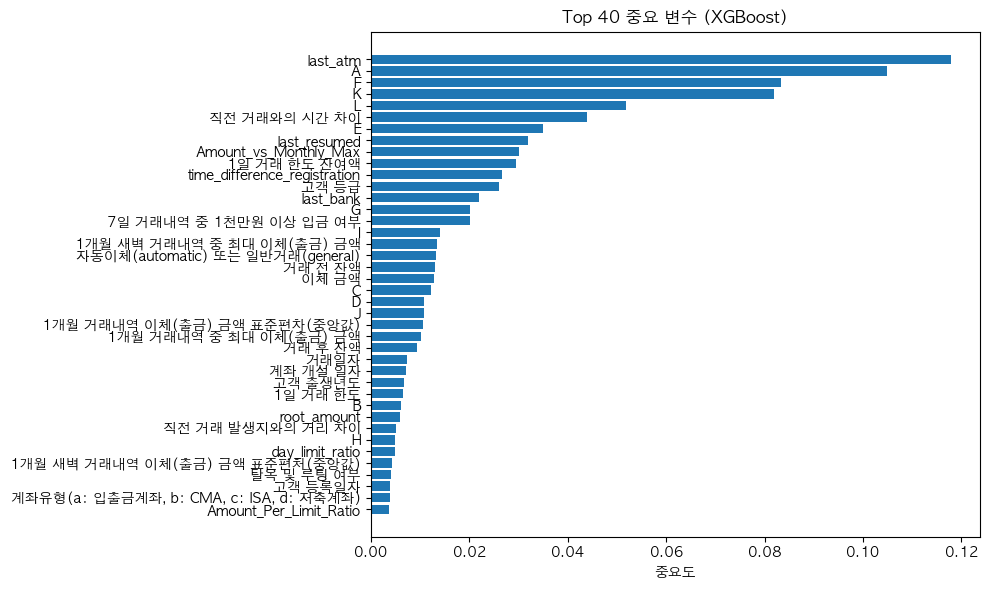

In [28]:
# 중요도 확인 + 시각화
importance_df = plot_xgb_feature_importance(model, train_x_encoded.columns, top_n=40)

In [29]:
importance_df['feature'].tail(30)

15                                                피싱 여부
46                                        마지막 영업점 거래 일자
68                               Is_Sudden_Balance_Drop
17                                               키로깅 여부
40    거래 시스템 접근 매체(a: ID/PW 로그인, b: 패턴, c: 생체로그인, d:...
75                                      changed_balance
16                                   신뢰할 수 없는 인증서 사용 여부
50                                3시간 이내 해당 수취계좌에 이체 횟수
11    대출 신청 유형(a: 없음, b: 신용대출, c: 담보대출, d: 할부금융, e: 기타)
12                                           전화번호 조작 여부
53                                         계좌의 거래 재개 일자
18                                   7일 이내 ATM 한도 문의 여부
36                                       거래에 사용한 단말기 OS
4                                 3개월 이내 금융/공동인증서 발급 여부
37    에러코드(a: 에러없음, b: 시스템 오류, c: 잔액부족, d: 이체한도초과, e...
49                                   수취계좌의 거래중지계좌 해당 여부
1                                                 고객 성별
13                                              

In [30]:

train_x.columns
# 컬럼개수 확인
print("train_x columns:", train_x.columns)
print("train_x shape:", train_x.shape)

train_x columns: Index(['고객 출생년도', '고객 성별', '고객 등록일자', '고객 등급', '3개월 이내 금융/공동인증서 발급 여부',
       '3개월 이내 사설인증서 발급 여부', '3개월 이내 보안카드 및 OTP 발급 여부', '3개월 이내 개인정보 수정 여부',
       '탈옥 및 루팅 여부', '모바일 로밍 여부', 'VPN 사용 여부',
       '대출 신청 유형(a: 없음, b: 신용대출, c: 담보대출, d: 할부금융, e: 기타)', '전화번호 조작 여부',
       '원격제어 여부', '템퍼링 여부', '피싱 여부', '신뢰할 수 없는 인증서 사용 여부', '키로깅 여부',
       '7일 이내 ATM 한도 문의 여부', '7일 이내 ATM 한도 증액 여부',
       '계좌유형(a: 입출금계좌, b: CMA, c: ISA, d: 저축계좌)', '계좌 개설 일자', '거래 전 잔액',
       '거래 후 잔액', '거래한도 증가 여부', '1일 거래 한도', '오픈뱅킹 사용 여부', '1일 거래 한도 잔여액',
       '30일 이내 계좌 정지 해제 여부', '1개월 거래내역 중 최대 이체(출금) 금액',
       '1개월 거래내역 이체(출금) 금액 표준편차(중앙값)', '1개월 새벽 거래내역 중 최대 이체(출금) 금액',
       '1개월 새벽 거래내역 이체(출금) 금액 표준편처(중앙값)', '거래일자', '이체 금액', '거래 채널',
       '거래에 사용한 단말기 OS',
       '에러코드(a: 에러없음, b: 시스템 오류, c: 잔액부족, d: 이체한도초과, e: 계좌정보 오류, f: 계좌이체 거부)',
       '거래 성공/실패 여부', '자동이체(automatic) 또는 일반거래(general)',
       '거래 시스템 접근 매체(a: ID/PW 로그인, b: 패턴, c: 생체로그인, d: 금융/공동 인증서, e: 사설인증서, f: 보안카드, g: OTP

In [31]:
# 파생변수가 포함된 train 데이터 저장
train_x.to_csv("trained.csv", index=False, encoding='utf-8-sig')